# Preprocessing the input data

This notebook mainly follows the same preprocessing steps of the following notebook
   - `https://www.kaggle.com/code/mehedihasanrafid/fixed-brain-tumor-mri-preprocessing-notebook`

The dataset consists of three image sets:
   - `https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset`
   - `https://www.kaggle.com/datasets/alamshihab075/brain-tumor-mri-dataset-for-deep-learning`
   - `https://www.kaggle.com/datasets/ishans24/brain-tumor-dataset`

For proper preprocessing, these datasets should be downloaded into local workspace and saved within a `raw_data` folder

## 1. Imports and configuration

In [1]:
import os
import shutil
import hashlib
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

SEED = 42
np.random.seed(SEED)

IMG_SIZE = (224, 224)
CANONICAL_CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".gif")


################################
###    CHANGE THIS BASED ON YOUR PATH.
################################
MAIN_DIRECTORY = "/home/onuro/code/simonwilliams32/MRI_project"


RAW_DATA_DIR = os.path.join(MAIN_DIRECTORY, "raw_data")
PREPROCESSED_DIR = os.path.join(RAW_DATA_DIR, "preprocessed_all_brain_tumor_images")
FINAL_DATASET_DIR = os.path.join(RAW_DATA_DIR, "final_brain_tumor_preprocessed_dataset")
REPORT_DIR = os.path.join(RAW_DATA_DIR, "preprocessing_reports")

os.makedirs(REPORT_DIR, exist_ok=True)

print("Configuration ready.")
print("Image size:", IMG_SIZE)
print("Final dataset directory:", FINAL_DATASET_DIR)


# if your files are in a different folder, adjust this part accordingly
dataset_paths = {
    "Masoud": os.path.join(RAW_DATA_DIR, "brain-tumor-mri-dataset"),
    "Ishans24": os.path.join(RAW_DATA_DIR, "brain-tumor-dataset"),
    "Alamshihab075": os.path.join(RAW_DATA_DIR, "brain-tumor-mri-dataset-for-deep-learning"),
}


Configuration ready.
Image size: (224, 224)
Final dataset directory: /home/onuro/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset


## 2. Class-name normalization

In [2]:
class_aliases = {
    "glioma": "glioma",
    "glioma tumor": "glioma",
    "glioma tumour": "glioma",
    "glioma_tumor": "glioma",
    "glioma-tumor": "glioma",
    "meningioma": "meningioma",
    "meningioma tumor": "meningioma",
    "meningioma tumour": "meningioma",
    "meningioma_tumor": "meningioma",
    "meningioma-tumor": "meningioma",
    "pituitary": "pituitary",
    "pituitary tumor": "pituitary",
    "pituitary tumour": "pituitary",
    "pituitary_tumor": "pituitary",
    "pituitary-tumor": "pituitary",
    "notumor": "notumor",
    "no tumor": "notumor",
    "no tumour": "notumor",
    "no_tumor": "notumor",
    "no-tumor": "notumor",
    "normal": "notumor",
    "non tumor": "notumor",
    "non_tumor": "notumor",
    "non-tumor": "notumor",
}


def normalize_text(text):
    text = str(text).lower().strip()
    text = text.replace("_", " ").replace("-", " ")
    text = " ".join(text.split())
    return text


def detect_class_from_path(path):
    for part in Path(path).parts:
        normalized = normalize_text(part)
        if normalized in class_aliases:
            return class_aliases[normalized]
    return None

## 3. Collect image paths

In [3]:
def collect_images(dataset_name, dataset_path):
    rows = []
    skipped_unknown_class = 0

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if not file.lower().endswith(IMAGE_EXTS):
                continue

            image_path = os.path.join(root, file)
            detected_class = detect_class_from_path(image_path)

            if detected_class is None:
                skipped_unknown_class += 1
                continue

            rows.append({
                "Dataset": dataset_name,
                "Original Path": image_path,
                "Class": detected_class,
                "Original Filename": file,
                "Original Relative Path": os.path.relpath(image_path, dataset_path),
                "Original Folder": os.path.relpath(root, dataset_path),
                "Original Extension": Path(file).suffix.lower(),
            })

    return rows, skipped_unknown_class


all_rows = []
skipped_summary = []

for dataset_name, dataset_path in dataset_paths.items():
    rows, skipped = collect_images(dataset_name, dataset_path)
    print(f"{dataset_name}: found {len(rows)} class-detected images; skipped {skipped} unknown-class images.")
    all_rows.extend(rows)
    skipped_summary.append({
        "Dataset": dataset_name,
        "Detected Images": len(rows),
        "Skipped Unknown Class": skipped,
    })

raw_df = pd.DataFrame(all_rows)

if raw_df.empty:
    raise ValueError("No images were detected. Check folder structure and class mappings.")

display(pd.DataFrame(skipped_summary))
print("Total detected images:", len(raw_df))
display(raw_df.head())

raw_counts = (
    raw_df.groupby(["Dataset", "Class"])
    .size()
    .reset_index(name="Raw Image Count")
    .sort_values(["Dataset", "Class"])
)

display(raw_counts)

raw_df.to_csv(os.path.join(REPORT_DIR, "01_raw_detected_images.csv"), index=False)
raw_counts.to_csv(os.path.join(REPORT_DIR, "02_raw_class_counts.csv"), index=False)

Masoud: found 7200 class-detected images; skipped 0 unknown-class images.
Ishans24: found 10560 class-detected images; skipped 0 unknown-class images.
Alamshihab075: found 9257 class-detected images; skipped 0 unknown-class images.


,Dataset,Detected Images,Skipped Unknown Class
0,Masoud,7200,0
1,Ishans24,10560,0
2,Alamshihab075,9257,0


Total detected images: 27017


,Dataset,Original Path,Class,Original Filename,Original Relative Path,Original Folder,Original Extension
0,Masoud,/home/onuro/code/simonwilliams32/MRI_project/r...,meningioma,Te-me_247.jpg,Testing/meningioma/Te-me_247.jpg,Testing/meningioma,.jpg
1,Masoud,/home/onuro/code/simonwilliams32/MRI_project/r...,meningioma,Te-me_139.jpg,Testing/meningioma/Te-me_139.jpg,Testing/meningioma,.jpg
2,Masoud,/home/onuro/code/simonwilliams32/MRI_project/r...,meningioma,Te-me_37.jpg,Testing/meningioma/Te-me_37.jpg,Testing/meningioma,.jpg
3,Masoud,/home/onuro/code/simonwilliams32/MRI_project/r...,meningioma,Te-aug-me_2.jpg,Testing/meningioma/Te-aug-me_2.jpg,Testing/meningioma,.jpg
4,Masoud,/home/onuro/code/simonwilliams32/MRI_project/r...,meningioma,Te-aug-me_65.jpg,Testing/meningioma/Te-aug-me_65.jpg,Testing/meningioma,.jpg


,Dataset,Class,Raw Image Count
0,Alamshihab075,glioma,3293
1,Alamshihab075,meningioma,3593
2,Alamshihab075,notumor,811
3,Alamshihab075,pituitary,1560
4,Ishans24,glioma,3754
5,Ishans24,meningioma,2343
6,Ishans24,notumor,1757
7,Ishans24,pituitary,2706
8,Masoud,glioma,1800
9,Masoud,meningioma,1800


## 4. Preprocess every image and hash preprocessed pixels

In [4]:
def reset_directory(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)


# Reset preprocessing output to avoid mixing old and new runs.
reset_directory(PREPROCESSED_DIR)

try:
    RESAMPLE_FILTER = Image.Resampling.LANCZOS
except AttributeError:
    RESAMPLE_FILTER = Image.LANCZOS


def preprocess_image(image_path, img_size=IMG_SIZE):
    with Image.open(image_path) as img:
        img = img.convert("RGB")
        img = img.resize(img_size, RESAMPLE_FILTER)
    return img


def hash_preprocessed_image(img):
    arr = np.asarray(img)
    return hashlib.md5(arr.tobytes()).hexdigest()


processed_rows = []
failed_rows = []

total_images = len(raw_df)
for idx, row in raw_df.reset_index(drop=True).iterrows():
    dataset_name = row["Dataset"]
    class_name = row["Class"]
    original_path = row["Original Path"]

    try:
        img = preprocess_image(original_path, img_size=IMG_SIZE)
        img_hash = hash_preprocessed_image(img)

        save_dir = os.path.join(PREPROCESSED_DIR, dataset_name, class_name)
        os.makedirs(save_dir, exist_ok=True)

        save_filename = f"{dataset_name}_{idx:06d}_{img_hash}.png"
        save_path = os.path.join(save_dir, save_filename)
        img.save(save_path, format="PNG")

        processed_rows.append({
            "Dataset": dataset_name,
            "Class": class_name,
            "Original Path": original_path,
            "Original Relative Path": row["Original Relative Path"],
            "Processed Path": save_path,
            "Preprocessed Hash": img_hash,
            "Width": IMG_SIZE[0],
            "Height": IMG_SIZE[1],
            "Mode": "RGB",
        })
    except Exception as e:
        failed_rows.append({
            "Dataset": dataset_name,
            "Class": class_name,
            "Original Path": original_path,
            "Error": str(e),
        })

    if (idx + 1) % 2000 == 0 or (idx + 1) == total_images:
        print(f"Processed {idx + 1}/{total_images} images...")

processed_df = pd.DataFrame(processed_rows)
failed_df = pd.DataFrame(failed_rows)

if processed_df.empty:
    raise ValueError("All preprocessing failed; no processed images were created.")

print("Total preprocessed images:", len(processed_df))
print("Failed images:", len(failed_df))

display(processed_df.head())

processed_counts = (
    processed_df.groupby(["Dataset", "Class"])
    .size()
    .reset_index(name="Preprocessed Count")
    .sort_values(["Dataset", "Class"])
)

display(processed_counts)

processed_df.to_csv(os.path.join(REPORT_DIR, "03_preprocessed_images.csv"), index=False)
processed_counts.to_csv(os.path.join(REPORT_DIR, "04_preprocessed_class_counts.csv"), index=False)
failed_df.to_csv(os.path.join(REPORT_DIR, "05_failed_preprocessing.csv"), index=False)

Processed 2000/27017 images...
Processed 4000/27017 images...
Processed 6000/27017 images...
Processed 8000/27017 images...
Processed 10000/27017 images...
Processed 12000/27017 images...
Processed 14000/27017 images...
Processed 16000/27017 images...
Processed 18000/27017 images...
Processed 20000/27017 images...
Processed 22000/27017 images...
Processed 24000/27017 images...
Processed 26000/27017 images...
Processed 27017/27017 images...
Total preprocessed images: 27017
Failed images: 0


,Dataset,Class,Original Path,Original Relative Path,Processed Path,Preprocessed Hash,Width,Height,Mode
0,Masoud,meningioma,/home/onuro/code/simonwilliams32/MRI_project/r...,Testing/meningioma/Te-me_247.jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,9cc4d062954c138b32007b9e6fef6e18,224,224,RGB
1,Masoud,meningioma,/home/onuro/code/simonwilliams32/MRI_project/r...,Testing/meningioma/Te-me_139.jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,285870cd44ad77c77758993decf560df,224,224,RGB
2,Masoud,meningioma,/home/onuro/code/simonwilliams32/MRI_project/r...,Testing/meningioma/Te-me_37.jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,5532e92d81d53c6c9ea4cba874a0258d,224,224,RGB
3,Masoud,meningioma,/home/onuro/code/simonwilliams32/MRI_project/r...,Testing/meningioma/Te-aug-me_2.jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,cec1ab3d8cd1bd58d2ec7514e88769e8,224,224,RGB
4,Masoud,meningioma,/home/onuro/code/simonwilliams32/MRI_project/r...,Testing/meningioma/Te-aug-me_65.jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,1d52da2fd9959d57d244d0a8736bf720,224,224,RGB


,Dataset,Class,Preprocessed Count
0,Alamshihab075,glioma,3293
1,Alamshihab075,meningioma,3593
2,Alamshihab075,notumor,811
3,Alamshihab075,pituitary,1560
4,Ishans24,glioma,3754
5,Ishans24,meningioma,2343
6,Ishans24,notumor,1757
7,Ishans24,pituitary,2706
8,Masoud,glioma,1800
9,Masoud,meningioma,1800


## 5. Find duplicates after preprocessing

In [5]:
duplicate_df = (
    processed_df.groupby("Preprocessed Hash")
    .filter(lambda x: len(x) > 1)
    .sort_values(["Preprocessed Hash", "Dataset", "Class"])
    .reset_index(drop=True)
)

if duplicate_df.empty:
    duplicate_hash_summary_df = pd.DataFrame(columns=[
        "Preprocessed Hash", "Duplicate_Entries", "Number_of_Datasets", "Classes", "Datasets"
    ])
    cross_dataset_duplicate_hashes_df = duplicate_hash_summary_df.copy()
else:
    duplicate_hash_summary_df = (
        duplicate_df.groupby("Preprocessed Hash")
        .agg(
            Duplicate_Entries=("Preprocessed Hash", "size"),
            Number_of_Datasets=("Dataset", "nunique"),
            Classes=("Class", lambda x: ", ".join(sorted(set(x)))),
            Datasets=("Dataset", lambda x: ", ".join(sorted(set(x)))),
        )
        .reset_index()
        .sort_values(["Number_of_Datasets", "Duplicate_Entries"], ascending=False)
    )

    cross_dataset_duplicate_hashes_df = duplicate_hash_summary_df[
        duplicate_hash_summary_df["Number_of_Datasets"] > 1
    ].copy()

print("Duplicate image entries after preprocessing:", len(duplicate_df))
print("Duplicate hash groups:", duplicate_df["Preprocessed Hash"].nunique() if not duplicate_df.empty else 0)
print("Duplicate hash groups appearing in more than one dataset:", len(cross_dataset_duplicate_hashes_df))

display(duplicate_df.head(100))
display(cross_dataset_duplicate_hashes_df.head(100))

duplicate_df.to_csv(os.path.join(REPORT_DIR, "06_duplicate_entries_after_preprocessing.csv"), index=False)
duplicate_hash_summary_df.to_csv(os.path.join(REPORT_DIR, "07_duplicate_hash_summary.csv"), index=False)
cross_dataset_duplicate_hashes_df.to_csv(os.path.join(REPORT_DIR, "08_cross_dataset_duplicate_hashes.csv"), index=False)

Duplicate image entries after preprocessing: 19590
Duplicate hash groups: 7175
Duplicate hash groups appearing in more than one dataset: 7175


,Dataset,Class,Original Path,Original Relative Path,Processed Path,Preprocessed Hash,Width,Height,Mode
0,Alamshihab075,pituitary,/home/onuro/code/simonwilliams32/MRI_project/r...,Train/Train/Pituitary/images/p (584).jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,000296ed3f14282e340765e5d7b24227,224,224,RGB
1,Alamshihab075,pituitary,/home/onuro/code/simonwilliams32/MRI_project/r...,test/test/Pituitary/images/Tr-pi_0532.jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,000296ed3f14282e340765e5d7b24227,224,224,RGB
2,Ishans24,pituitary,/home/onuro/code/simonwilliams32/MRI_project/r...,pituitary/pituitary1165.jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,000296ed3f14282e340765e5d7b24227,224,224,RGB
3,Masoud,pituitary,/home/onuro/code/simonwilliams32/MRI_project/r...,Training/pituitary/Tr-pi_24.jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,000296ed3f14282e340765e5d7b24227,224,224,RGB
4,Alamshihab075,meningioma,/home/onuro/code/simonwilliams32/MRI_project/r...,Train/Train/Meningioma/images/Tr-me_0460.jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,0004a762d764396f8f5518caf1640432,224,224,RGB
...,...,...,...,...,...,...,...,...,...
95,Ishans24,meningioma,/home/onuro/code/simonwilliams32/MRI_project/r...,meningioma/meningioma827.jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,011681873205e53c70e8c730e3fa64e4,224,224,RGB
96,Masoud,meningioma,/home/onuro/code/simonwilliams32/MRI_project/r...,Training/meningioma/Tr-me_1133.jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,011681873205e53c70e8c730e3fa64e4,224,224,RGB
97,Alamshihab075,meningioma,/home/onuro/code/simonwilliams32/MRI_project/r...,Train/Train/Meningioma/images/m2 (55).jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,011b482b57166bb39b8c42911eeb46e2,224,224,RGB
98,Ishans24,meningioma,/home/onuro/code/simonwilliams32/MRI_project/r...,meningioma/meningioma1065.jpg,/home/onuro/code/simonwilliams32/MRI_project/r...,011b482b57166bb39b8c42911eeb46e2,224,224,RGB


,Preprocessed Hash,Duplicate_Entries,Number_of_Datasets,Classes,Datasets
2082,4948cd41e195a81192b2c160952197ee,16,3,notumor,"Alamshihab075, Ishans24, Masoud"
1216,2ae817c198efa08837133cb845fd29b0,13,3,meningioma,"Alamshihab075, Ishans24, Masoud"
518,1210952b4e54f23ce1450e6c04f01211,12,3,notumor,"Alamshihab075, Ishans24, Masoud"
1473,344396fa3b3359533286e8bd1cd22bce,11,3,notumor,"Alamshihab075, Ishans24, Masoud"
2448,55caee96126e665a1b54070e234359a0,11,3,notumor,"Alamshihab075, Ishans24, Masoud"
...,...,...,...,...,...
5716,ca2fa9b233e253611aafd605053cb9b6,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"
5864,cf5761e4ba32866383a43edb2a571647,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"
6080,d71bf2b41416468598fb73cb26909c79,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"
6188,db306467e793f4e4474e0f313370ec21,6,3,meningioma,"Alamshihab075, Ishans24, Masoud"


## 6. Deduplicate Masoud + Ishans24 for internal train/validation/test

In [6]:
internal_sources = ["Masoud", "Ishans24","Alamshihab075"]
internal_df = processed_df[processed_df["Dataset"].isin(internal_sources)].copy()

if internal_df.empty:
    raise ValueError("Internal pool is empty. Masoud and Ishans24 images were not found.")

source_priority = {"Masoud": 0, "Ishans24": 1, "Alamshihab075": 2}
internal_df["Source Priority"] = internal_df["Dataset"].map(source_priority)

internal_dedup_df = (
    internal_df.sort_values(["Preprocessed Hash", "Source Priority", "Dataset"])
    .drop_duplicates(subset=["Preprocessed Hash"], keep="first")
    .reset_index(drop=True)
)

print("Internal source images before deduplication:", len(internal_df))
print("Internal source images after deduplication:", len(internal_dedup_df))
print("Removed internal duplicates:", len(internal_df) - len(internal_dedup_df))

internal_dataset_class_counts = (
    internal_dedup_df.groupby(["Dataset", "Class"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Dataset", "Class"])
)
internal_class_counts = (
    internal_dedup_df.groupby("Class")
    .size()
    .reset_index(name="Count")
    .sort_values("Class")
)

display(internal_dataset_class_counts)
display(internal_class_counts)

internal_dedup_df.to_csv(os.path.join(REPORT_DIR, "09_internal_masoud_ishans24_deduplicated.csv"), index=False)
internal_class_counts.to_csv(os.path.join(REPORT_DIR, "10_internal_deduplicated_class_counts.csv"), index=False)

Internal source images before deduplication: 27017
Internal source images after deduplication: 14602
Removed internal duplicates: 12415


,Dataset,Class,Count
0,Alamshihab075,glioma,2004
1,Alamshihab075,meningioma,2004
2,Ishans24,glioma,1959
3,Ishans24,meningioma,746
4,Ishans24,notumor,75
5,Ishans24,pituitary,936
6,Masoud,glioma,1779
7,Masoud,meningioma,1684
8,Masoud,notumor,1657
9,Masoud,pituitary,1758


,Class,Count
0,glioma,5742
1,meningioma,4434
2,notumor,1732
3,pituitary,2694


## 7. Deduplicate Alamshihab075 for external validation

In [ ]:
# this step will be skipped and all images will be used in train / validation / test split
# this cell can be run without problem.

#alam_df = processed_df[processed_df["Dataset"] == "Alamshihab075"].copy()
alam_df = pd.DataFrame(columns=processed_df.columns)

if alam_df.empty:
    print("WARNING: Alamshihab075 pool is empty. External validation will be empty.")
    external_dedup_df = alam_df.copy()
else:
    internal_hashes = set(internal_dedup_df["Preprocessed Hash"])

    # Remove duplicates inside Alamshihab075 first.
    alam_unique_df = (
        alam_df.drop_duplicates(subset=["Preprocessed Hash"], keep="first")
        .reset_index(drop=True)
    )

    # Remove any Alamshihab075 image that appears in the internal pool.
    external_dedup_df = alam_unique_df[
        ~alam_unique_df["Preprocessed Hash"].isin(internal_hashes)
    ].reset_index(drop=True)

    print("Alamshihab075 original preprocessed images:", len(alam_df))
    print("Alamshihab075 unique images:", len(alam_unique_df))
    print("Final external validation images:", len(external_dedup_df))
    print("Removed Alamshihab075 images duplicated with internal pool:", len(alam_unique_df) - len(external_dedup_df))

external_class_counts = (
    external_dedup_df.groupby("Class")
    .size()
    .reset_index(name="External Validation Count")
    .sort_values("Class")
)

display(external_class_counts)

external_dedup_df.to_csv(os.path.join(REPORT_DIR, "11_external_alamshihab075_deduplicated.csv"), index=False)
external_class_counts.to_csv(os.path.join(REPORT_DIR, "12_external_deduplicated_class_counts.csv"), index=False)

,Class,External Validation Count


## 8. Stratified split: train / validation / internal test

In [8]:
if len(internal_dedup_df) == 0:
    raise ValueError("Internal deduplicated dataset is empty.")

class_counts = internal_dedup_df["Class"].value_counts()
print("Internal class counts before split:")
display(class_counts.to_frame("Count"))

if (class_counts < 3).any():
    raise ValueError("At least one class has fewer than 3 images, so stratified splitting is unsafe.")

train_val_df, internal_test_df = train_test_split(
    internal_dedup_df,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=internal_dedup_df["Class"],
)

val_adjusted_ratio = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_adjusted_ratio,
    random_state=SEED,
    stratify=train_val_df["Class"],
)

split_summary_rows = []
for split_name, df in [
    ("train", train_df),
    ("val", val_df),
    ("test", internal_test_df),
    ("external_val", external_dedup_df),
]:
    for class_name in CANONICAL_CLASSES:
        count = int((df["Class"] == class_name).sum()) if not df.empty else 0
        split_summary_rows.append({"Split": split_name, "Class": class_name, "Count": count})

split_summary_df = pd.DataFrame(split_summary_rows)

print("Split sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Internal test:", len(internal_test_df))
print("External validation:", len(external_dedup_df))

display(split_summary_df)

train_df.to_csv(os.path.join(REPORT_DIR, "13_train_split.csv"), index=False)
val_df.to_csv(os.path.join(REPORT_DIR, "14_val_split.csv"), index=False)
internal_test_df.to_csv(os.path.join(REPORT_DIR, "15_internal_test_split.csv"), index=False)
split_summary_df.to_csv(os.path.join(REPORT_DIR, "16_final_split_class_counts.csv"), index=False)

Internal class counts before split:


,Count
Class,
glioma,5742
meningioma,4434
pituitary,2694
notumor,1732


Split sizes:
Train: 10220
Validation: 2191
Internal test: 2191
External validation: 0


,Split,Class,Count
0,train,glioma,4018
1,train,meningioma,3104
2,train,notumor,1212
3,train,pituitary,1886
4,val,glioma,862
5,val,meningioma,665
6,val,notumor,260
7,val,pituitary,404
8,test,glioma,862
9,test,meningioma,665


## 9. Create final folder dataset

In [9]:
reset_directory(FINAL_DATASET_DIR)

for split_name in ["train", "val", "test", "external_val"]:
    for class_name in CANONICAL_CLASSES:
        os.makedirs(os.path.join(FINAL_DATASET_DIR, split_name, class_name), exist_ok=True)


def copy_split_images(df, split_name):
    copied_rows = []
    if df.empty:
        return copied_rows

    for i, row in df.reset_index(drop=True).iterrows():
        src = row["Processed Path"]
        class_name = row["Class"]
        img_hash = row["Preprocessed Hash"]
        dataset_name = row["Dataset"]

        dst_filename = f"{split_name}_{dataset_name}_{i:06d}_{img_hash}.png"
        dst = os.path.join(FINAL_DATASET_DIR, split_name, class_name, dst_filename)
        shutil.copy2(src, dst)

        copied_rows.append({
            "Split": split_name,
            "Class": class_name,
            "Dataset": dataset_name,
            "Source Processed Path": src,
            "Final Path": dst,
            "Preprocessed Hash": img_hash,
        })

    return copied_rows


final_copy_rows = []
final_copy_rows.extend(copy_split_images(train_df, "train"))
final_copy_rows.extend(copy_split_images(val_df, "val"))
final_copy_rows.extend(copy_split_images(internal_test_df, "test"))
final_copy_rows.extend(copy_split_images(external_dedup_df, "external_val"))

final_manifest_df = pd.DataFrame(final_copy_rows)

print("Final dataset created at:")
print(FINAL_DATASET_DIR)
display(final_manifest_df.head())

final_manifest_df.to_csv(os.path.join(REPORT_DIR, "17_final_dataset_manifest.csv"), index=False)

Final dataset created at:
/home/onuro/code/simonwilliams32/MRI_project/raw_data/final_brain_tumor_preprocessed_dataset


,Split,Class,Dataset,Source Processed Path,Final Path,Preprocessed Hash
0,train,notumor,Masoud,/home/onuro/code/simonwilliams32/MRI_project/r...,/home/onuro/code/simonwilliams32/MRI_project/r...,886029d512ae9ff12171a3a4e1ef988c
1,train,meningioma,Alamshihab075,/home/onuro/code/simonwilliams32/MRI_project/r...,/home/onuro/code/simonwilliams32/MRI_project/r...,58e4d14928e522af36f10e3d3f004cd2
2,train,glioma,Ishans24,/home/onuro/code/simonwilliams32/MRI_project/r...,/home/onuro/code/simonwilliams32/MRI_project/r...,0ed611e1d4066112c4009123954acd3d
3,train,pituitary,Ishans24,/home/onuro/code/simonwilliams32/MRI_project/r...,/home/onuro/code/simonwilliams32/MRI_project/r...,c5f74ca88227fa700d4a8546ee6a2397
4,train,meningioma,Alamshihab075,/home/onuro/code/simonwilliams32/MRI_project/r...,/home/onuro/code/simonwilliams32/MRI_project/r...,62278a4943f3a928f2c0e4343313e22d


## 10. Verify final dataset and check duplicate leakage

In [10]:
def collect_final_images(final_dir):
    rows = []
    for split_name in ["train", "val", "test", "external_val"]:
        for class_name in CANONICAL_CLASSES:
            class_dir = os.path.join(final_dir, split_name, class_name)
            if not os.path.exists(class_dir):
                continue

            for file in os.listdir(class_dir):
                if not file.lower().endswith(".png"):
                    continue

                path = os.path.join(class_dir, file)
                try:
                    img = preprocess_image(path, img_size=IMG_SIZE)
                    img_hash = hash_preprocessed_image(img)
                except Exception as e:
                    print("Could not hash final image:", path, e)
                    img_hash = None

                rows.append({
                    "Split": split_name,
                    "Class": class_name,
                    "Path": path,
                    "Filename": file,
                    "Hash": img_hash,
                })
    return pd.DataFrame(rows)


final_check_df = collect_final_images(FINAL_DATASET_DIR)

print("Final total images:", len(final_check_df))

final_counts_df = (
    final_check_df.groupby(["Split", "Class"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Split", "Class"])
)

display(final_counts_df)

if final_check_df.empty:
    leakage_df = pd.DataFrame(columns=final_check_df.columns)
    within_split_duplicate_df = pd.DataFrame(columns=final_check_df.columns)
else:
    leakage_df = (
        final_check_df.groupby("Hash")
        .filter(lambda x: x["Split"].nunique() > 1)
        .sort_values(["Hash", "Split"])
        .reset_index(drop=True)
    )

    within_split_duplicate_df = (
        final_check_df.groupby(["Split", "Hash"])
        .filter(lambda x: len(x) > 1)
        .sort_values(["Split", "Hash"])
        .reset_index(drop=True)
    )

print("Duplicate leakage across train/val/test/external_val:", len(leakage_df))
if len(leakage_df) > 0:
    print("WARNING: Duplicate leakage found across splits.")
    display(leakage_df.head(100))
else:
    print("Good: no duplicate images across final splits.")

print("Duplicate entries within the same split:", len(within_split_duplicate_df))
if len(within_split_duplicate_df) > 0:
    display(within_split_duplicate_df.head(100))
else:
    print("Good: no duplicate entries within individual splits.")

final_check_df.to_csv(os.path.join(REPORT_DIR, "18_final_dataset_check.csv"), index=False)
final_counts_df.to_csv(os.path.join(REPORT_DIR, "19_final_dataset_counts.csv"), index=False)
leakage_df.to_csv(os.path.join(REPORT_DIR, "20_final_split_leakage_check.csv"), index=False)
within_split_duplicate_df.to_csv(os.path.join(REPORT_DIR, "21_final_within_split_duplicate_check.csv"), index=False)

Final total images: 14602


,Split,Class,Count
0,test,glioma,862
1,test,meningioma,665
2,test,notumor,260
3,test,pituitary,404
4,train,glioma,4018
5,train,meningioma,3104
6,train,notumor,1212
7,train,pituitary,1886
8,val,glioma,862
9,val,meningioma,665


Duplicate leakage across train/val/test/external_val: 0
Good: no duplicate images across final splits.
Duplicate entries within the same split: 0
Good: no duplicate entries within individual splits.


## 11. Plot final class distributions

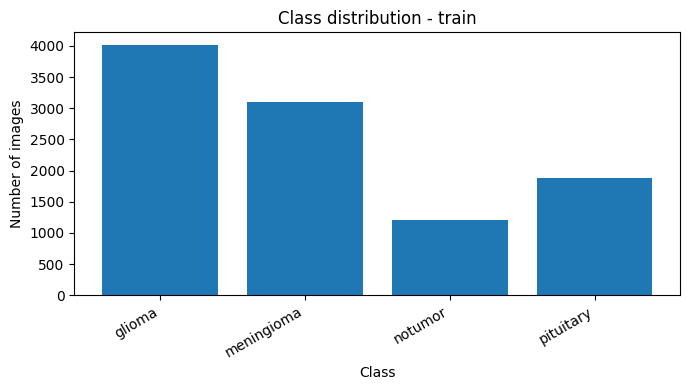

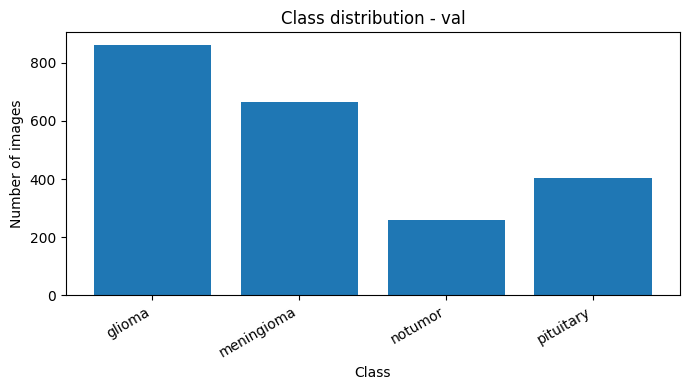

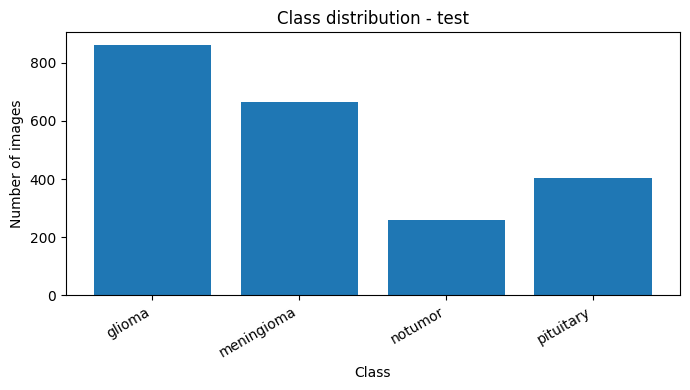

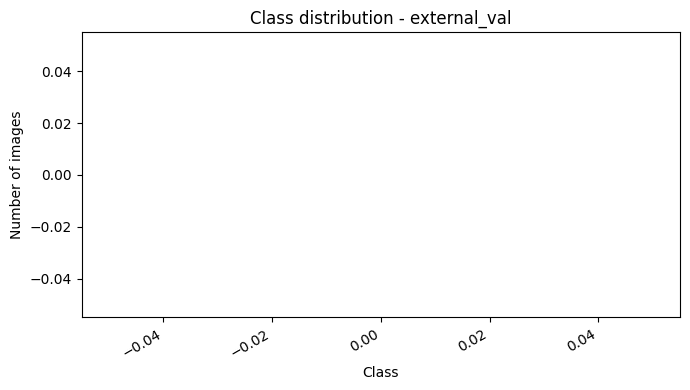

In [11]:
for split_name in ["train", "val", "test", "external_val"]:
    temp_df = final_counts_df[final_counts_df["Split"] == split_name]
    plt.figure(figsize=(7, 4))
    plt.bar(temp_df["Class"], temp_df["Count"])
    plt.title(f"Class distribution - {split_name}")
    plt.xlabel("Class")
    plt.ylabel("Number of images")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

## 12. Convert all images to grayscale

In [12]:

def is_grayscale(path):
    """Returns True if image is black & white (all RGB channels equal)"""
    try:
        img = Image.open(path).convert("RGB")
        arr = np.array(img)
        return np.array_equal(arr[:, :, 0], arr[:, :, 1]) and np.array_equal(arr[:, :, 1], arr[:, :, 2])
    except Exception as e:
        print(f"Error reading {path}: {e}")
        return None

results = []

for split in os.listdir(FINAL_DATASET_DIR):
    split_path = os.path.join(FINAL_DATASET_DIR, split)
    if not os.path.isdir(split_path):
        continue

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path):
            continue

        for fname in os.listdir(class_path):
            if not fname.lower().endswith(IMAGE_EXTS):
                continue
            fpath = os.path.join(class_path, fname)
            gray = is_grayscale(fpath)
            results.append({
                "split": split,
                "class": class_name,
                "filename": fname,
                "path": fpath,
                "is_grayscale": gray
            })

df = pd.DataFrame(results)

print(f"Total images checked: {len(df)}")
print(f"Grayscale: {(df['is_grayscale'] == True).sum()}")
print(f"Colormapped/Color: {(df['is_grayscale'] == False).sum()}")
print(f"Errors/unreadable: {df['is_grayscale'].isna().sum()}")

print("\nBreakdown by split and class:")
summary = df.groupby(["split", "class"])["is_grayscale"].value_counts().unstack(fill_value=0)
print(summary)


def convert_to_grayscale_and_save(path):
    """Convert an image to grayscale (L), then save it back as 3-channel RGB
    so shape/format stays consistent with the rest of the transfer learning pipeline."""
    try:
        img = Image.open(path).convert("RGB")
        gray = img.convert("L")
        gray_rgb = Image.merge("RGB", (gray, gray, gray))
        gray_rgb.save(path)
        return True
    except Exception as e:
        print(f"Error converting {path}: {e}")
        return False

# Only touch the ones flagged as colorized
to_fix = df[df["is_grayscale"] == False]
print(f"Converting {len(to_fix)} colorized images to grayscale...")

converted = 0
failed = 0
for path in to_fix["path"]:
    if convert_to_grayscale_and_save(path):
        converted += 1
    else:
        failed += 1

print(f"Converted: {converted}")
print(f"Failed: {failed}")


Total images checked: 14602
Grayscale: 11406
Colormapped/Color: 3196
Errors/unreadable: 0

Breakdown by split and class:
is_grayscale      False  True 
split class                   
test  glioma        216    646
      meningioma    102    563
      notumor        16    244
      pituitary     143    261
train glioma        983   3035
      meningioma    511   2593
      notumor       100   1112
      pituitary     629   1257
val   glioma        227    635
      meningioma     95    570
      notumor        16    244
      pituitary     158    246
Converting 3196 colorized images to grayscale...
Converted: 3196
Failed: 0


## 13. Show final sample images

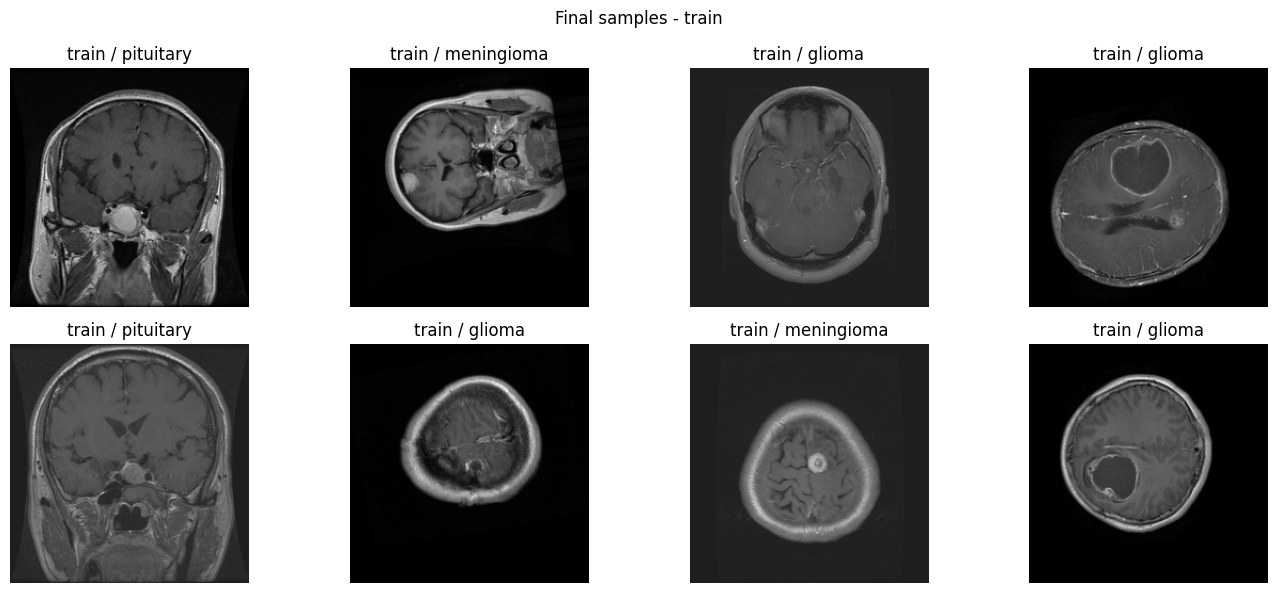

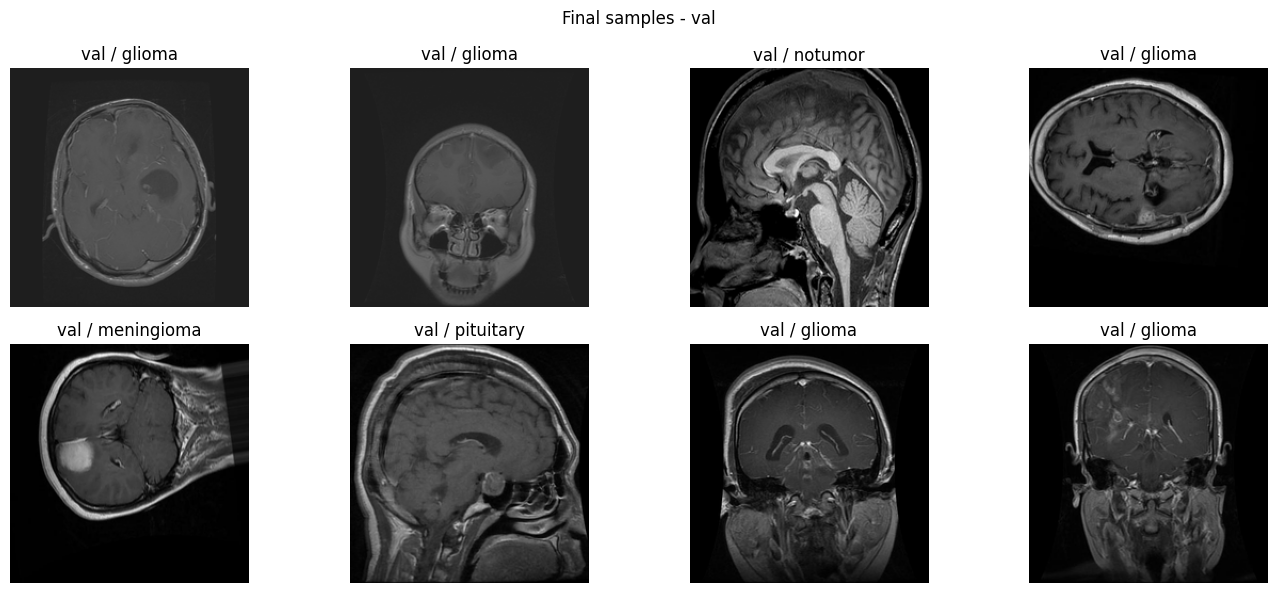

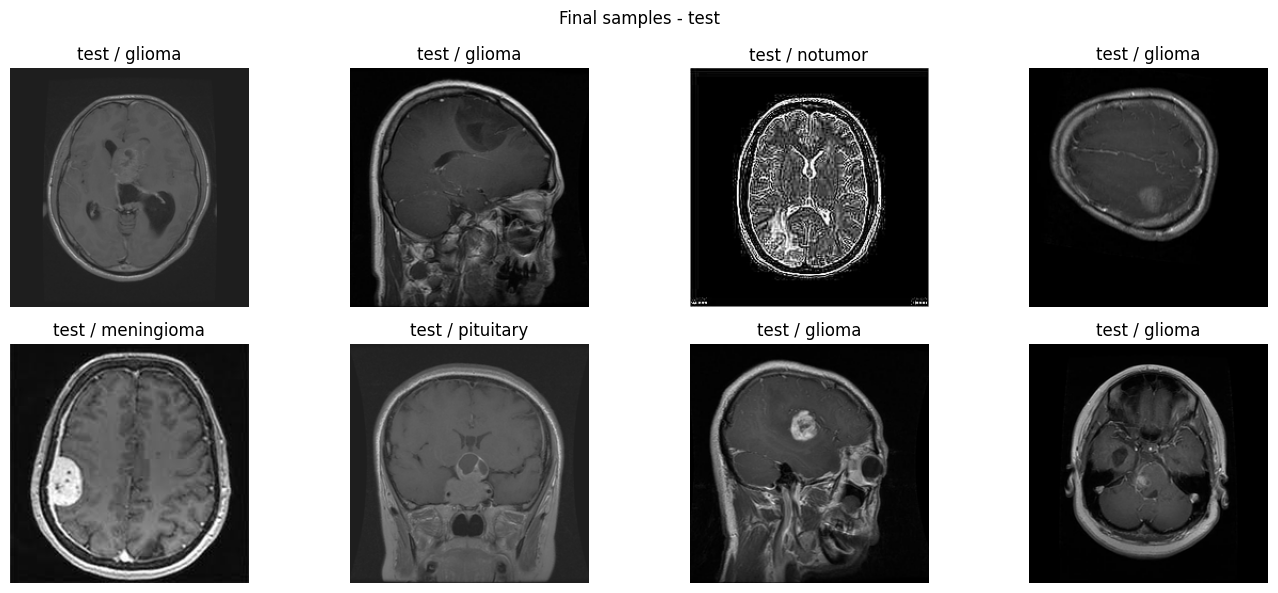

No images for split: external_val


In [13]:
def show_final_samples(split_name, n=8):
    temp_df = final_check_df[final_check_df["Split"] == split_name]
    if temp_df.empty:
        print("No images for split:", split_name)
        return

    sample_df = temp_df.sample(min(n, len(temp_df)), random_state=SEED)
    plt.figure(figsize=(14, 6))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["Path"])
        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(f"{row['Split']} / {row['Class']}")
        plt.axis("off")

    plt.suptitle(f"Final samples - {split_name}")
    plt.tight_layout()
    plt.show()


for split_name in ["train", "val", "test", "external_val"]:
    show_final_samples(split_name, n=8)

## 16. Use this output in your training notebook

In [14]:
""" # Copy this block into your model-training notebook after this preprocessing notebook finishes.

FINAL_DATASET_DIR = "/kaggle/working/final_brain_tumor_preprocessed_dataset"

TRAIN_DIR = FINAL_DATASET_DIR + "/train"
VAL_DIR = FINAL_DATASET_DIR + "/val"
TEST_DIR = FINAL_DATASET_DIR + "/test"
EXTERNAL_VAL_DIR = FINAL_DATASET_DIR + "/external_val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
class_names = ["glioma", "meningioma", "notumor", "pituitary"]

# Uncomment to load datasets directly here.
# import tensorflow as tf
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
#     label_mode="categorical", shuffle=True, class_names=class_names
# )
# val_ds = tf.keras.utils.image_dataset_from_directory(
#     VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
#     label_mode="categorical", shuffle=False, class_names=class_names
# )
# test_ds = tf.keras.utils.image_dataset_from_directory(
#     TEST_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
#     label_mode="categorical", shuffle=False, class_names=class_names
# )
# external_val_ds = tf.keras.utils.image_dataset_from_directory(
#     EXTERNAL_VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
#     label_mode="categorical", shuffle=False, class_names=class_names
# )
# AUTOTUNE = tf.data.AUTOTUNE
# train_ds = train_ds.prefetch(AUTOTUNE)
# val_ds = val_ds.prefetch(AUTOTUNE)
# test_ds = test_ds.prefetch(AUTOTUNE)
# external_val_ds = external_val_ds.prefetch(AUTOTUNE)

print("Training paths prepared:")
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)
print("EXTERNAL_VAL_DIR:", EXTERNAL_VAL_DIR) """

' # Copy this block into your model-training notebook after this preprocessing notebook finishes.\n\nFINAL_DATASET_DIR = "/kaggle/working/final_brain_tumor_preprocessed_dataset"\n\nTRAIN_DIR = FINAL_DATASET_DIR + "/train"\nVAL_DIR = FINAL_DATASET_DIR + "/val"\nTEST_DIR = FINAL_DATASET_DIR + "/test"\nEXTERNAL_VAL_DIR = FINAL_DATASET_DIR + "/external_val"\n\nIMG_SIZE = (224, 224)\nBATCH_SIZE = 32\nclass_names = ["glioma", "meningioma", "notumor", "pituitary"]\n\n# Uncomment to load datasets directly here.\n# import tensorflow as tf\n# train_ds = tf.keras.utils.image_dataset_from_directory(\n#     TRAIN_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,\n#     label_mode="categorical", shuffle=True, class_names=class_names\n# )\n# val_ds = tf.keras.utils.image_dataset_from_directory(\n#     VAL_DIR, image_size=IMG_SIZE, batch_size=BATCH_SIZE,\n#     label_mode="categorical", shuffle=False, class_names=class_names\n# )\n# test_ds = tf.keras.utils.image_dataset_from_directory(\n#     TEST_DIR